# Projeto: Dashboard Interativo com Pandas — Lifestyle Weight Tracker


Este trabalho tem como objetivo analisar um conjunto de dados de hábitos de vida e entender quais fatores estão mais ligados à variação de peso (`Weight_Change`).

A ideia principal é:
1. carregar os dados,
2. fazer uma análise exploratória,
3. tratar valores faltantes,
4. gerar gráficos simples,
5. tirar conclusões claras para apresentar em sala.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1) Ler os dados

Nesta etapa vamos carregar o arquivo CSV com o Pandas e observar:
- quantidade de linhas e colunas;
- primeiras linhas da tabela (`head`);
- nomes das variáveis disponíveis.

Isso ajuda a entender o que pode ser analisado antes de começar os gráficos.

In [2]:
df = pd.read_csv("lifestyle weight tracker.csv")

print("Formato: (quant de linhas, quant de colunas) ==", df.shape)
display(df.head())


Formato: (quant de linhas, quant de colunas) == (55000, 18)


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Type,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
0,275,23,Female,169.355325,111.485330,10,7.016453,211.426469,2801.764291,175.1,315.2,93.4,8172,Strength,6,18.823955,0.317158,111.802488
1,296,43,Female,174.424939,109.699334,1,7.320227,211.979739,2666.001616,166.6,299.9,88.9,7988,NaN,0,36.987432,0.211877,109.911211
2,125,47,Male,163.246320,110.960286,3,7.238641,160.400067,1707.084012,106.7,192.0,56.9,7976,Yoga,10,35.977033,0.122390,111.082676
3,167,42,Female,164.997333,85.546097,7,5.060697,301.629856,2647.458547,165.5,297.8,88.2,8203,Cardio,10,33.141805,0.308449,85.854547
4,311,54,Male,167.696168,135.710505,5,9.866791,335.199126,2036.567163,127.3,229.1,67.9,8024,NaN,0,19.065076,0.120221,135.830726


In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            55000 non-null  int64  
 1   Age                55000 non-null  int64  
 2   Gender             55000 non-null  object 
 3   Height_cm          55000 non-null  float64
 4   Initial_Weight_kg  55000 non-null  float64
 5   Stress_Level       55000 non-null  int64  
 6   Sleep_Hours        55000 non-null  float64
 7   Caffeine_mg        55000 non-null  float64
 8   Calories_Consumed  52250 non-null  float64
 9   Protein_g          55000 non-null  float64
 10  Carbs_g            55000 non-null  float64
 11  Fat_g              55000 non-null  float64
 12  Steps              55000 non-null  int64  
 13  Workout_Type       27448 non-null  object 
 14  Workout_Intensity  55000 non-null  int64  
 15  Temp_C             55000 non-null  float64
 16  Weight_Change      550

None

## 2) Verificar dados faltando

Aqui vamos identificar colunas com valores nulos (vazios).

Por que isso é importante?
- valores faltantes podem atrapalhar médias, correlações e gráficos;
- antes de analisar, precisamos decidir como tratar esses dados;
- essa decisão precisa ser justificada no trabalho.

In [4]:
faltando = df.isnull().sum()
faltando[faltando > 0]

Calories_Consumed     2750
Workout_Type         27552
dtype: int64

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

quality_report = pd.DataFrame({
    "missing_qtd": missing,
    "missing_%": missing_pct
})

print("Linhas duplicadas:", df.duplicated().sum())
display(quality_report[quality_report["missing_qtd"] > 0])

display(df.describe(include="all").T)

Linhas duplicadas: 0


,missing_qtd,missing_%
Workout_Type,27552,50.09
Calories_Consumed,2750,5.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,55000.0,NaN,NaN,NaN,349.4414,144.343054,100.0,224.0,350.0,474.0,599.0
Age,55000.0,NaN,NaN,NaN,40.918545,13.539751,18.0,29.0,41.0,53.0,64.0
Gender,55000,3,Male,26438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,55000.0,NaN,NaN,NaN,169.972335,9.991794,126.190233,163.27336,169.984098,176.675947,213.837588
Initial_Weight_kg,55000.0,NaN,NaN,NaN,114.999924,17.291936,85.000325,100.032148,115.032495,129.899387,144.998228
Stress_Level,55000.0,NaN,NaN,NaN,5.524964,2.881427,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,55000.0,NaN,NaN,NaN,6.66634,1.543146,3.0,5.610998,6.659498,7.714812,11.0
Caffeine_mg,55000.0,NaN,NaN,NaN,261.091734,114.579046,0.0,181.968341,260.645919,339.196616,740.175153
Calories_Consumed,52250.0,NaN,NaN,NaN,2097.729693,601.919105,-327.404484,1693.339924,2095.328161,2501.645667,4874.404173
Protein_g,55000.0,NaN,NaN,NaN,131.073911,37.583689,-20.5,105.8,130.9,156.3,304.7


## 3) Tratamento dos dados

Tratamentos escolhidos (simples e eficientes):
- `Workout_Type`: valores vazios serão preenchidos com `"None"` (sem treino registrado).
- `Calories_Consumed`: valores vazios serão preenchidos com a mediana da coluna.

Justificativa:
- é um método fácil de explicar;
- mantém todas as linhas do dataset;
- evita perder dados desnecessariamente.

In [6]:
df.isnull().sum().sum() # total de nulos antes do tratamento

np.int64(30302)

In [7]:
df["Workout_Type"] = df["Workout_Type"].fillna("None")
df["Calories_Consumed"] = df["Calories_Consumed"].fillna(df["Calories_Consumed"].median())

df.isnull().sum().sum()  # total de nulos depois do tratamento

np.int64(0)

In [8]:
# df_clean = df.copy()

# # 1) Workout_Type ausente -> "None"
# df_clean["Workout_Type"] = df_clean["Workout_Type"].fillna("None")

# # 2) Imputação de Calories_Consumed por grupo
# group_median = (
#     df_clean.groupby(["Stress_Level", "Workout_Type"])["Calories_Consumed"]
#     .transform("median")
# )
# global_median = df_clean["Calories_Consumed"].median()
# df_clean["Calories_Consumed"] = df_clean["Calories_Consumed"].fillna(group_median)
# df_clean["Calories_Consumed"] = df_clean["Calories_Consumed"].fillna(global_median)

# # 3) Feature engineering
# df_clean["Height_m"] = df_clean["Height_cm"] / 100
# df_clean["BMI"] = df_clean["Current_Weight_kg"] / (df_clean["Height_m"] ** 2)
# df_clean["Calorie_Density"] = df_clean["Calories_Consumed"] / (df_clean["Current_Weight_kg"] + 1e-6)

# # Checagem final de ausências
# display(df_clean.isna().sum().sort_values(ascending=False).head(10))

## 4) Estatísticas básicas

Agora vamos gerar estatísticas descritivas das variáveis principais, como:
- média,
- desvio padrão,
- mínimo e máximo,
- quartis.

Isso permite ter uma visão geral dos dados antes de interpretar os gráficos.

In [9]:
df[["Weight_Change", "Calories_Consumed", "Sleep_Hours", "Stress_Level"]].describe()

,Weight_Change,Calories_Consumed,Sleep_Hours,Stress_Level
count,55000.000000,55000.000000,55000.000000,55000.000000
mean,0.168459,2097.609616,6.666340,5.524964
std,0.105259,586.678125,1.543146,2.881427
min,-0.250723,-327.404484,3.000000,1.000000
25%,0.096170,1717.941102,5.610998,3.000000
50%,0.168383,2095.328161,6.659498,6.000000
75%,0.241079,2477.570547,7.714812,8.000000
max,0.593711,4874.404173,11.000000,10.000000


Foi indentificado valores negativos que causam inconsistencia, por exemplo em "Calories_Consumed"

In [10]:
# transformar calorias negativas em NaN
df.loc[df["Calories_Consumed"] < 0, "Calories_Consumed"] = pd.NA

# preencher com mediana
df["Calories_Consumed"] = df["Calories_Consumed"].fillna(df["Calories_Consumed"].median())

In [11]:
df[["Weight_Change", "Calories_Consumed", "Sleep_Hours", "Stress_Level"]].describe()

,Weight_Change,Calories_Consumed,Sleep_Hours,Stress_Level
count,55000.000000,55000.000000,55000.000000,55000.000000
mean,0.168459,2098.173613,6.666340,5.524964
std,0.105259,585.606983,1.543146,2.881427
min,-0.250723,9.506851,3.000000,1.000000
25%,0.096170,1718.317929,5.610998,3.000000
50%,0.168383,2095.328161,6.659498,6.000000
75%,0.241079,2477.570547,7.714812,8.000000
max,0.593711,4874.404173,11.000000,10.000000


In [12]:
# 1) Ver todas as linhas do User_ID 271
df[df["User_ID"] == 271]

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Type,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
451,271,59,Male,174.233918,104.998346,7,8.572281,180.031013,2434.472202,152.2,273.9,81.1,8059,None,0,30.238434,0.267472,105.265817
1439,271,64,Male,162.078618,122.058039,2,6.788700,146.429797,2505.320342,156.6,281.8,83.5,7848,None,0,20.284106,0.128660,122.454171
1450,271,18,Male,173.143194,102.274462,3,8.012175,244.963924,2574.840108,160.9,289.7,85.8,7989,None,0,26.726051,0.188723,102.859316
1782,271,57,Male,168.606756,144.108545,9,4.601675,291.414593,2042.851047,127.7,229.8,68.1,8037,Strength,6,25.353068,0.232368,144.925768
2001,271,21,Female,192.590745,95.549852,7,8.474613,286.503743,1502.548267,93.9,169.0,50.1,7974,None,0,28.705210,0.139485,96.506559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52606,271,20,Male,163.859673,129.500890,8,7.386236,289.179706,1965.188652,122.8,221.1,65.5,7980,Cardio,9,25.298789,0.202486,147.207913
52793,271,49,Female,153.921007,111.138275,9,6.167855,433.295131,1938.138582,121.1,218.0,64.6,8068,Strength,4,31.448543,0.248988,129.094286
53265,271,44,Other,172.661697,127.469402,4,7.563929,30.262944,1765.143160,110.3,198.6,58.8,7982,None,0,29.220775,0.116099,145.541513
53686,271,46,Male,170.789000,124.472556,4,3.948772,468.853646,1756.674687,109.8,197.6,58.6,7931,None,0,19.051309,0.064577,142.609244


In [13]:
# 2) Ranking dos menores consumos de calorias (linhas individuais)
ranking = (
    df[["User_ID", "Calories_Consumed", "Gender", "Age"]]
    .dropna(subset=["Calories_Consumed"])
    .sort_values("Calories_Consumed", ascending=True)
)

ranking.head(15)  # mostra o menor e os próximos

,User_ID,Calories_Consumed,Gender,Age
36170,271,9.506851,Male,19
11818,430,22.300810,Male,48
37872,368,40.008578,Female,64
20740,205,61.492185,Male,50
29560,359,68.743447,Female,63
8034,590,78.270518,Female,52
6957,230,92.104756,Male,46
32008,110,98.825994,Male,48
9133,323,101.755874,Female,56
52766,136,106.384792,Female,62


In [14]:
# achar a primeira posição do 271 no ranking
pos_271 = ranking.index[ranking["User_ID"] == 271][0]

# pegar os próximos 10 após ele
ranking.loc[pos_271:].head(11)   # inclui ele + 10 próximos

,User_ID,Calories_Consumed,Gender,Age
36170,271,9.506851,Male,19
11818,430,22.300810,Male,48
37872,368,40.008578,Female,64
20740,205,61.492185,Male,50
29560,359,68.743447,Female,63
8034,590,78.270518,Female,52
6957,230,92.104756,Male,46
32008,110,98.825994,Male,48
9133,323,101.755874,Female,56
52766,136,106.384792,Female,62


NameError: name 'df_clean' is not defined

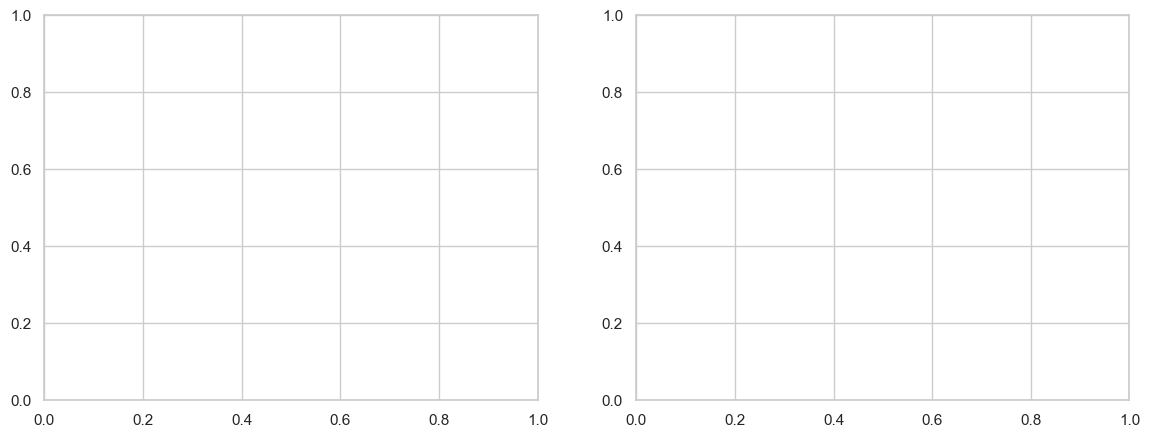

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["Weight_Change"], kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Distribuição de Weight_Change")

sns.boxplot(data=df_clean, y="Weight_Change", ax=axes[1], color="orange")
axes[1].set_title("Boxplot de Weight_Change")

plt.tight_layout()
plt.show()

## 5) Gráficos simples para análise

Serão usados 3 gráficos principais:

1. **Histograma de `Weight_Change`**
   - mostra como a variação de peso se distribui nos dados.

2. **Dispersão: `Calories_Consumed` x `Weight_Change`**
   - ajuda a ver se maior consumo de calorias está ligado a maior variação de peso.

3. **Boxplot por `Workout_Type`**
   - compara a variação de peso entre tipos de treino.

## Célula 12

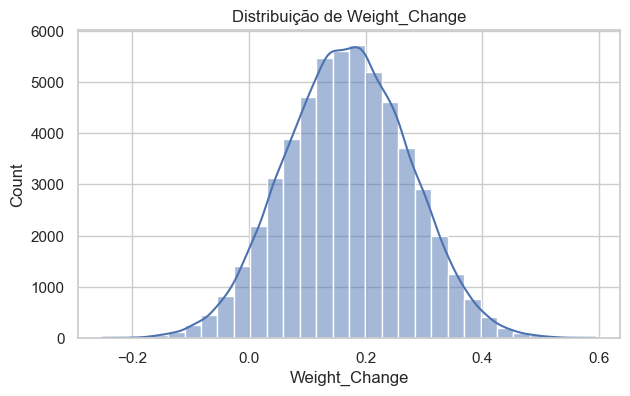

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["Weight_Change"], bins=30, kde=True)
plt.title("Distribuição de Weight_Change")
plt.show()

## Célula 13


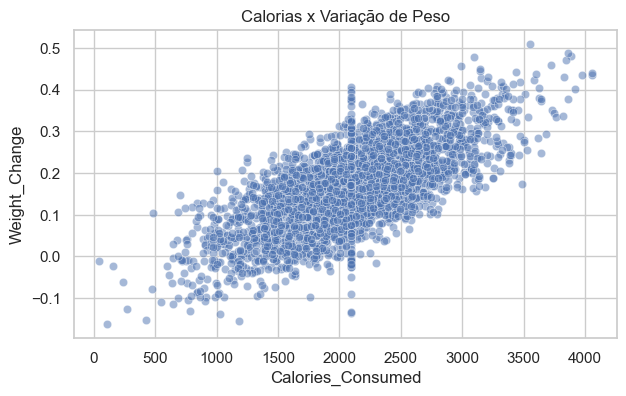

In [ ]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=df.sample(3000, random_state=1), x="Calories_Consumed", y="Weight_Change", alpha=0.5)
plt.title("Calorias x Variação de Peso")
plt.show()

# Célula 14

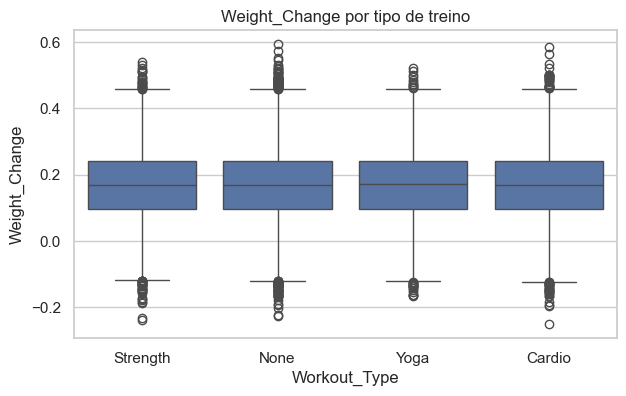

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Workout_Type", y="Weight_Change")
plt.title("Weight_Change por tipo de treino")
plt.show()

## Interpretação dos gráficos (Células 12, 13 e 14)

### Célula 12 — Histograma de `Weight_Change`
Este gráfico mostra como os valores de variação de peso estão distribuídos no conjunto de dados.  
Com ele, conseguimos identificar:
- qual faixa de variação de peso é mais comum entre os usuários;
- se há concentração de valores próximos da média;
- presença de valores extremos (muito altos ou muito baixos), que podem indicar outliers.

Em resumo, esse gráfico ajuda a entender o comportamento geral da variável principal do projeto.

### Célula 13 — Dispersão `Calories_Consumed` x `Weight_Change`
Este gráfico permite observar a relação entre calorias consumidas e variação de peso.  
Cada ponto representa um registro do dataset.

Com ele, conseguimos perceber:
- se existe tendência de aumento de `Weight_Change` quando `Calories_Consumed` aumenta;
- a dispersão dos dados (se a relação é forte ou fraca);
- possíveis exceções (pontos fora do padrão geral).

Em resumo, ele ajuda a investigar se o consumo calórico está associado ao ganho ou perda de peso.

### Célula 14 — Boxplot de `Weight_Change` por `Workout_Type`
Esse gráfico compara a variação de peso entre os tipos de treino (`Cardio`, `Strength`, `Yoga` e `None`).  
Com ele, conseguimos analisar:
- mediana de `Weight_Change` em cada grupo;
- intervalo interquartil (dispersão dentro de cada tipo de treino);
- outliers em cada categoria;
- se há diferenças relevantes entre os grupos.

Em resumo, esse gráfico mostra se o tipo de treino parece influenciar a variação de peso e como os grupos se comparam entre si.

## 6) Correlação (insight rápido)

A correlação mede a força da relação entre duas variáveis:
- perto de **+1**: relação positiva forte;
- perto de **-1**: relação negativa forte;
- perto de **0**: relação fraca.

Vamos focar em como cada variável se relaciona com `Weight_Change`.

In [ ]:
corr = df[["Weight_Change", "Calories_Consumed", "Sleep_Hours", "Stress_Level", "Caffeine_mg"]].corr()
corr["Weight_Change"].sort_values(ascending=False)

Weight_Change        1.000000
Calories_Consumed    0.726177
Stress_Level         0.554500
Caffeine_mg          0.279670
Sleep_Hours         -0.156174
Name: Weight_Change, dtype: float64

## 7) Insights para a apresentação

Com base nas análises, os principais pontos para apresentar são:

1. `Calories_Consumed` tem relação positiva com `Weight_Change`.
2. `Stress_Level` também apresenta relação positiva com a variação de peso.
3. `Sleep_Hours` tende a ter relação negativa com `Weight_Change`.
4. `Workout_Type` possui muitos valores faltantes no dataset original, o que também é um achado importante sobre qualidade de dados.

Esses resultados indicam que alimentação, estresse e sono são fatores relevantes neste conjunto.

## 8) Salvar base tratada

Por fim, vamos exportar o dataset já tratado para um novo arquivo CSV.

Esse arquivo pode ser usado:
- no dashboard final (Streamlit/Power BI),
- ou como base padronizada para futuras análises.

In [ ]:
df.to_csv("dataset_tratado.csv", index=False)
print("Arquivo salvo: dataset_tratado.csv")

Arquivo salvo: dataset_tratado.csv
